In [128]:
import os
import json
import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit

In [129]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [130]:
BASE_DIR = (
    "/content/drive/MyDrive/"
    "Delhivery_Graph_ETA"
)

MODEL_DIR = f"{BASE_DIR}/models"
REPORT_DIR = f"{BASE_DIR}/reports"


In [131]:
model = joblib.load(
    f"{MODEL_DIR}/lgbm_final_graph_edge.pkl"
)

In [132]:
prep = model.named_steps["prep"]

lgbm_model = model.named_steps["lgbm"]

In [133]:
with open(
    f"{MODEL_DIR}/lgbm_final_graph_edge_features.json"
) as f:
    model_features = json.load(f)

In [134]:
with open(
    f"{MODEL_DIR}/lgbm_final_graph_edge_metrics.json"
) as f:
    model_metrics = json.load(f)

model_metrics

{'MAE': 0.40563727077378936,
 'RMSE': 0.9365621247401877,
 'R2': 0.6369884361696732,
 'MAPE': 18.67229710107841}

In [135]:
dataset_path = (
    f"{BASE_DIR}/data/feature_store/"
    "model_dataset.csv"
)

df = pd.read_csv(dataset_path)

print(df.shape)

(144867, 120)


In [136]:
print(df["trip_uuid"].nunique())

14817


In [137]:
groups = df["trip_uuid"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        groups=groups
    )
)

In [138]:
test_df = df.iloc[test_idx].copy()

print(test_df.shape)

(28416, 120)


In [139]:
X_test = test_df[model_features]

y_test = test_df["factor"]

In [140]:
X_processed = prep.transform(
    X_test
)

In [141]:
feature_names = (
    prep.get_feature_names_out()
)

In [142]:
print(X_processed.shape)

print(len(feature_names))

(28416, 288)
288


In [143]:
explainer = shap.TreeExplainer(
    lgbm_model
)

In [144]:
shap_values = explainer.shap_values(
    X_processed
)

In [145]:
print(shap_values.shape)

print(len(feature_names))

(28416, 288)
288


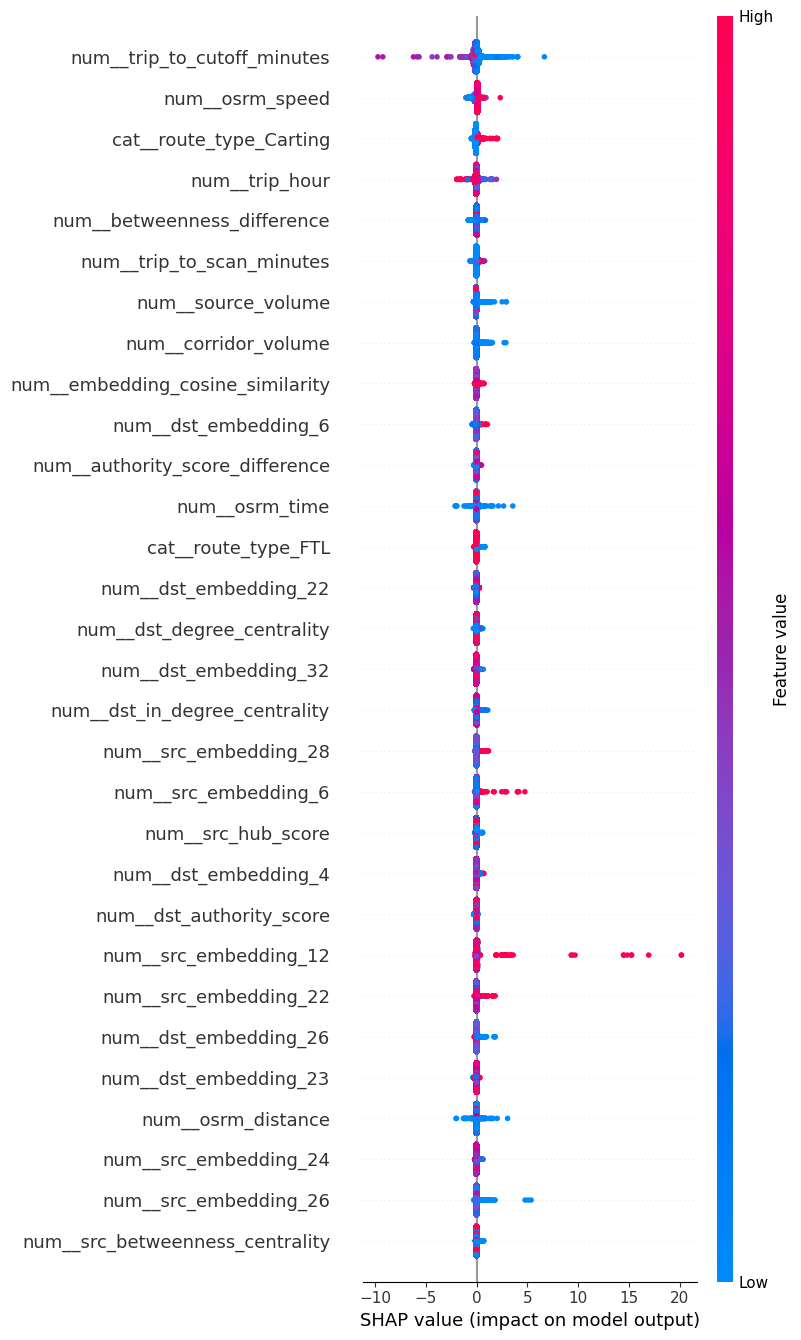

In [146]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    max_display=30
)

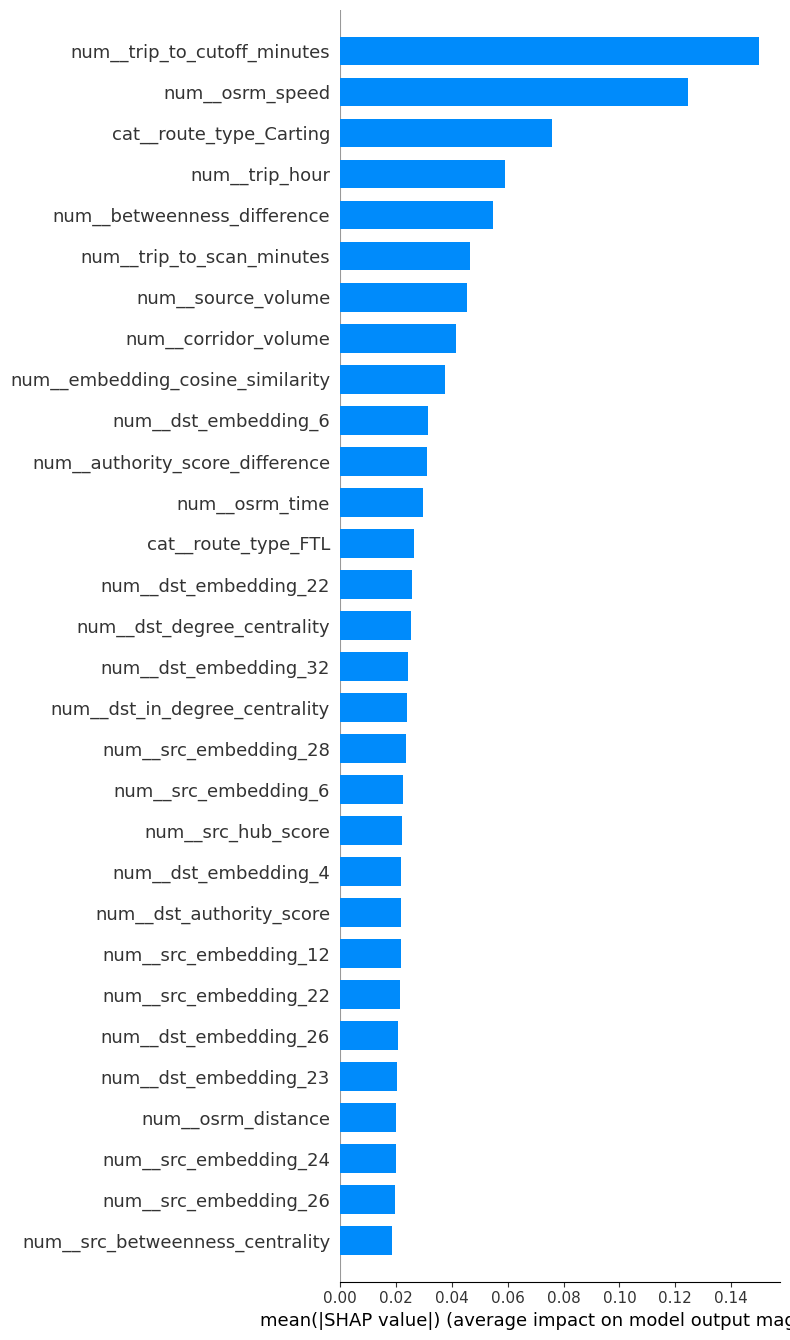

In [147]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=30
)

In [148]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(
        shap_values
    ).mean(axis=0)
})

In [149]:
importance_df = (
    importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

In [150]:
importance_df.head(30)

,feature,mean_abs_shap
0,num__trip_to_cutoff_minutes,0.149940
1,num__osrm_speed,0.124493
2,cat__route_type_Carting,0.075812
3,num__trip_hour,0.058914
4,num__betweenness_difference,0.054667
5,num__trip_to_scan_minutes,0.046648
6,num__source_volume,0.045459
7,num__corridor_volume,0.041696
8,num__embedding_cosine_similarity,0.037519
9,num__dst_embedding_6,0.031485


In [151]:
importance_df.to_csv(
    f"{REPORT_DIR}/phase7_global_feature_importance.csv",
    index=False
)

In [152]:
print(len(feature_names))

288


In [153]:
print(
    importance_df.shape
)

(288, 2)


In [154]:
importance_df.head(20)

,feature,mean_abs_shap
0,num__trip_to_cutoff_minutes,0.149940
1,num__osrm_speed,0.124493
2,cat__route_type_Carting,0.075812
3,num__trip_hour,0.058914
4,num__betweenness_difference,0.054667
5,num__trip_to_scan_minutes,0.046648
6,num__source_volume,0.045459
7,num__corridor_volume,0.041696
8,num__embedding_cosine_similarity,0.037519
9,num__dst_embedding_6,0.031485


In [155]:
all_features = importance_df["feature"].tolist()

In [156]:
traditional_features = [
    f for f in all_features
    if (
        f.startswith("num__osrm")
        or f.startswith("num__trip_")
        or f.startswith("num__source_volume")
        or f.startswith("num__destination_volume")
        or f.startswith("num__corridor_volume")
        or f.startswith("cat__route_type")
    )
]

In [157]:
centrality_features = [
    f for f in all_features
    if (
        (
            "centrality" in f
            or "pagerank" in f
            or "hub_score" in f
            or "authority_score" in f
            or "closeness" in f
        )
        and "difference" not in f
    )
]

In [158]:
community_features = [
    f for f in all_features
    if (
        "community_id" in f
        or "community_size" in f
    )
]

In [159]:
embedding_features = [
    f for f in all_features
    if (
        "embedding_" in f
        and "cosine" not in f
    )
]

In [160]:
edge_features = [
    f for f in all_features
    if (
        "difference" in f
        or "cosine_similarity" in f
        or "same_community" in f
    )
]

In [161]:
print(len(traditional_features))
print(len(centrality_features))
print(len(community_features))
print(len(embedding_features))
print(len(edge_features))

13
16
188
64
6


In [162]:
centrality_score = importance_df[
    importance_df.feature.isin(centrality_features)
]["mean_abs_shap"].sum()

edge_score = importance_df[
    importance_df.feature.isin(edge_features)
]["mean_abs_shap"].sum()

embedding_score = importance_df[
    importance_df.feature.isin(embedding_features)
]["mean_abs_shap"].sum()

community_score = importance_df[
    importance_df.feature.isin(community_features)
]["mean_abs_shap"].sum()

print("Centrality :", centrality_score)
print("Edge       :", edge_score)
print("Embeddings :", embedding_score)
print("Community  :", community_score)

Centrality : 0.18256427301784883
Edge       : 0.14238730029714922
Embeddings : 0.7181198282632288
Community  : 0.0577079200770782


In [163]:
graph_total = (
    embedding_score
    + centrality_score
    + edge_score
    + community_score
)

graph_breakdown = pd.DataFrame({

    "Component": [
        "Embeddings",
        "Centrality",
        "Edge Intelligence",
        "Community"
    ],

    "Importance": [
        embedding_score,
        centrality_score,
        edge_score,
        community_score
    ]
})

graph_breakdown["Graph_%"] = (
    100
    * graph_breakdown["Importance"]
    / graph_total
)

graph_breakdown = (
    graph_breakdown
    .sort_values(
        "Graph_%",
        ascending=False
    )
)

graph_breakdown

,Component,Importance,Graph_%
0,Embeddings,0.718120,65.237402
1,Centrality,0.182564,16.585002
2,Edge Intelligence,0.142387,12.935136
3,Community,0.057708,5.242460


Node2Vec embeddings account for approximately 65% of graph-derived explanatory power, indicating that latent network structure contributes more to ETA prediction than classical graph centrality measures. Centrality metrics contribute approximately 17%, edge intelligence features contribute approximately 13%, and community structure contributes approximately 5%. This suggests that facility position within the network matters, but learned representations of corridor behavior and network context carry substantially richer ETA information.

In [164]:
shap_values
feature_names

array(['cat__route_type_Carting', 'cat__route_type_FTL',
       'cat__src_community_id_0', 'cat__src_community_id_1',
       'cat__src_community_id_2', 'cat__src_community_id_3',
       'cat__src_community_id_4', 'cat__src_community_id_5',
       'cat__src_community_id_6', 'cat__src_community_id_7',
       'cat__src_community_id_8', 'cat__src_community_id_9',
       'cat__src_community_id_10', 'cat__src_community_id_11',
       'cat__src_community_id_12', 'cat__src_community_id_13',
       'cat__src_community_id_14', 'cat__src_community_id_15',
       'cat__src_community_id_16', 'cat__src_community_id_17',
       'cat__src_community_id_18', 'cat__src_community_id_19',
       'cat__src_community_id_20', 'cat__src_community_id_21',
       'cat__src_community_id_22', 'cat__src_community_id_23',
       'cat__src_community_id_24', 'cat__src_community_id_25',
       'cat__src_community_id_26', 'cat__src_community_id_27',
       'cat__src_community_id_28', 'cat__src_community_id_29',
       '

In [165]:
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)

shap_df.head()

,cat__route_type_Carting,cat__route_type_FTL,cat__src_community_id_0,cat__src_community_id_1,cat__src_community_id_2,cat__src_community_id_3,cat__src_community_id_4,cat__src_community_id_5,cat__src_community_id_6,cat__src_community_id_7,...,num__dst_embedding_29,num__dst_embedding_30,num__dst_embedding_31,num__dst_embedding_32,num__same_community,num__pagerank_difference,num__betweenness_difference,num__hub_score_difference,num__authority_score_difference,num__embedding_cosine_similarity
0,0.095839,0.035208,0.0,0.000227,0.0,-0.000017,-0.000016,0.0,0.0,-0.000685,...,0.006403,-0.008958,0.009681,-0.031520,-4.136778e-07,0.014461,0.019685,-0.000036,-0.005130,0.020327
1,0.104617,0.035613,0.0,0.000205,0.0,-0.000017,-0.000016,0.0,0.0,-0.000691,...,0.002004,-0.005496,0.011754,-0.036117,-4.136778e-07,0.014580,0.021517,-0.000788,-0.005413,0.015136
2,0.130296,0.040070,0.0,0.000213,0.0,-0.000034,-0.000016,0.0,0.0,-0.000705,...,0.001602,-0.003476,0.010990,-0.040005,-4.136778e-07,0.014985,0.024455,0.002339,-0.010550,0.035990
3,0.125755,0.040130,0.0,-0.000059,0.0,-0.000034,-0.000016,0.0,0.0,-0.000704,...,0.001802,-0.004155,0.010889,-0.037705,-4.136778e-07,0.014971,0.022621,-0.001081,-0.009392,0.018908
4,0.121988,0.051518,0.0,0.000022,0.0,0.048332,-0.000016,0.0,0.0,-0.000087,...,-0.001358,-0.000279,-0.023443,0.020038,-1.617648e-04,-0.017584,-0.149759,-0.000841,-0.030440,-0.009145


In [166]:
positive_importance = []

for col in shap_df.columns:

    vals = shap_df.loc[
        shap_df[col] > 0,
        col
    ]

    positive_importance.append({

        "feature": col,

        "mean_positive_shap":
        vals.mean()
        if len(vals) > 0
        else 0

    })

In [167]:
positive_df = pd.DataFrame(
    positive_importance
)

In [168]:
positive_df = (
    positive_df
    .sort_values(
        "mean_positive_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

In [169]:
positive_df.head(30)

,feature,mean_positive_shap
0,cat__src_community_id_17,0.582988
1,cat__src_community_id_74,0.522700
2,cat__src_community_id_45,0.361507
3,cat__dst_community_id_45,0.322479
4,num__trip_to_cutoff_minutes,0.166922
5,cat__dst_community_id_34,0.155531
6,cat__dst_community_id_74,0.106502
7,cat__route_type_Carting,0.098471
8,num__osrm_speed,0.089162
9,num__corridor_volume,0.088738


In [170]:
positive_df.to_csv(
    f"{REPORT_DIR}/phase7_eta_inflation_drivers.csv",
    index=False
)

In [171]:
inflation_business = positive_df[
    ~positive_df["feature"].str.contains(
        "community_id"
    )
].copy()

In [172]:
inflation_business.head(30)

,feature,mean_positive_shap
4,num__trip_to_cutoff_minutes,0.166922
7,cat__route_type_Carting,0.098471
8,num__osrm_speed,0.089162
9,num__corridor_volume,0.088738
10,num__trip_to_scan_minutes,0.082762
13,num__source_volume,0.068466
14,num__src_embedding_12,0.061648
15,num__trip_hour,0.057765
18,num__src_embedding_26,0.053177
19,num__dst_embedding_30,0.051912


In [173]:
inflation_business.to_csv(
    f"{REPORT_DIR}/phase7_eta_inflation_drivers_business.csv",
    index=False
)

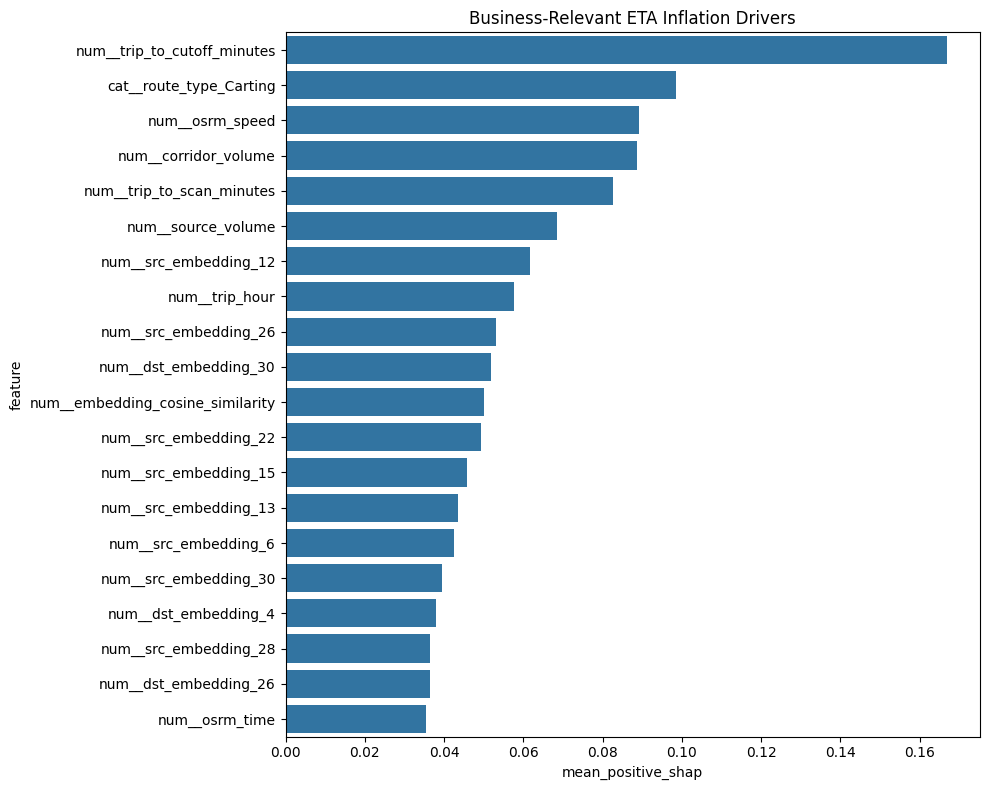

In [174]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=inflation_business.head(20),
    x="mean_positive_shap",
    y="feature"
)

plt.title(
    "Business-Relevant ETA Inflation Drivers"
)

plt.tight_layout()

plt.show()

In [175]:
inflation_business.head(20)

,feature,mean_positive_shap
4,num__trip_to_cutoff_minutes,0.166922
7,cat__route_type_Carting,0.098471
8,num__osrm_speed,0.089162
9,num__corridor_volume,0.088738
10,num__trip_to_scan_minutes,0.082762
13,num__source_volume,0.068466
14,num__src_embedding_12,0.061648
15,num__trip_hour,0.057765
18,num__src_embedding_26,0.053177
19,num__dst_embedding_30,0.051912


In [176]:
negative_importance = []

for col in shap_df.columns:

    vals = shap_df.loc[
        shap_df[col] < 0,
        col
    ]

    negative_importance.append({

        "feature": col,

        "mean_negative_shap":
        abs(vals.mean())
        if len(vals) > 0
        else 0

    })

In [177]:
negative_df = pd.DataFrame(
    negative_importance
)

In [178]:
negative_df = (
    negative_df
    .sort_values(
        "mean_negative_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

In [179]:
reduction_business = negative_df[
    ~negative_df["feature"].str.contains(
        "community_id"
    )
].copy()

In [180]:
reduction_business["family"] = (
    reduction_business["feature"]
    .apply(classify_feature)
)

In [181]:
reduction_business.head(30)

,feature,mean_negative_shap,family
0,num__osrm_speed,0.191976,Traditional
1,num__betweenness_difference,0.145091,Edge Intelligence
2,num__trip_to_cutoff_minutes,0.139418,Traditional
3,cat__route_type_Carting,0.064934,Traditional
4,num__dst_authority_score,0.060068,Centrality
5,num__trip_hour,0.060010,Traditional
7,num__authority_score_difference,0.035862,Edge Intelligence
8,num__dst_embedding_23,0.035254,Embeddings
9,num__source_volume,0.034848,Traditional
10,num__dst_degree_centrality,0.032109,Centrality


In [182]:
reduction_business.to_csv(
    f"{REPORT_DIR}/phase7_eta_reduction_drivers.csv",
    index=False
)

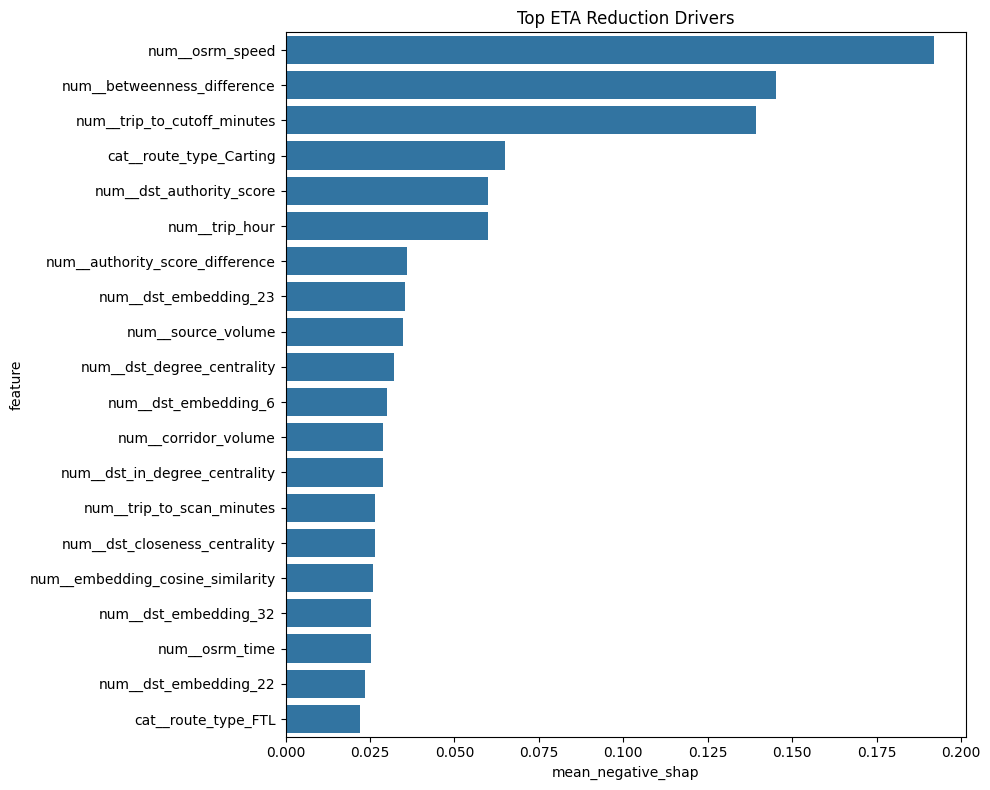

In [183]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=reduction_business.head(20),
    x="mean_negative_shap",
    y="feature"
)

plt.title(
    "Top ETA Reduction Drivers"
)

plt.tight_layout()

plt.show()

In [184]:
shap_explanation = shap.Explanation(
    values=shap_values,
    data=X_processed,
    feature_names=feature_names
)

In [185]:
preds = lgbm_model.predict(
    X_processed
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [186]:
test_df["pred_factor"] = preds

In [187]:
worst_shipments = (
    test_df
    .sort_values(
        "pred_factor",
        ascending=False
    )
)

In [188]:
worst_shipments[
    [
        "trip_uuid",
        "pred_factor",
        "factor"
    ]
].head(20)

,trip_uuid,pred_factor,factor
132914,trip-153793221526410461,56.636662,50.684211
34326,trip-153697923702522443,56.008357,63.666667
34327,trip-153697923702522443,55.148891,49.900000
63425,trip-153750335607956765,40.024183,63.500000
109626,trip-153705622336805088,37.915504,36.666667
119520,trip-153826219212835068,36.804758,52.714286
34328,trip-153697923702522443,35.122186,31.875000
63426,trip-153750335607956765,34.280662,31.184211
34329,trip-153697923702522443,34.225269,28.000000
132915,trip-153793221526410461,33.089423,31.343750


In [189]:
worst_idx = worst_shipments.index[0]

In [190]:
row_pos = np.where(
    test_df.index == worst_idx
)[0][0]

In [191]:
expected_value = explainer.expected_value

print(expected_value)

2.1247010589035367


In [192]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.repeat(
        expected_value,
        X_processed.shape[0]
    ),
    data=X_processed,
    feature_names=feature_names
)

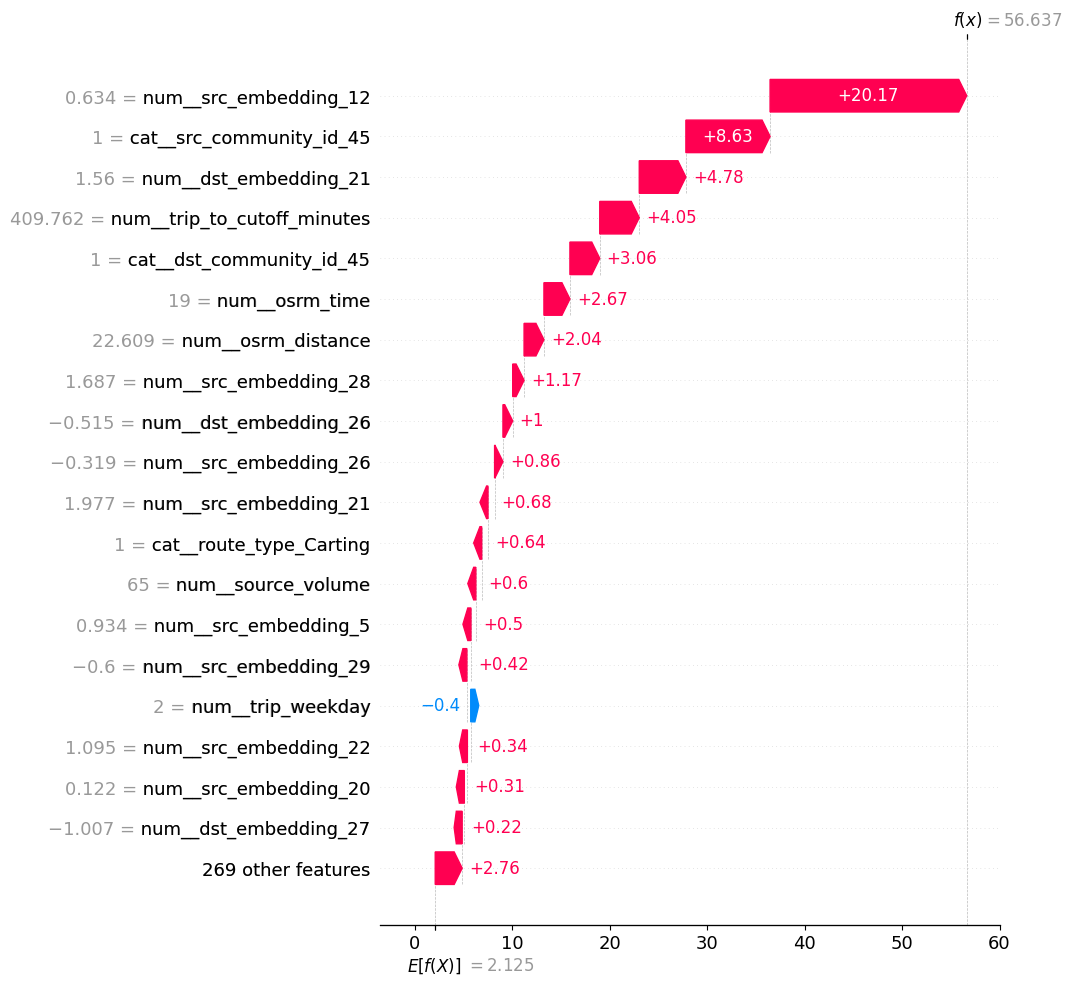

In [193]:
shap.plots.waterfall(
    shap_explanation[row_pos],
    max_display=20
)

In [194]:
top_delay_indices = (
    worst_shipments.index[:10]
)


Trip: trip-153793221526410461


<Axes: >

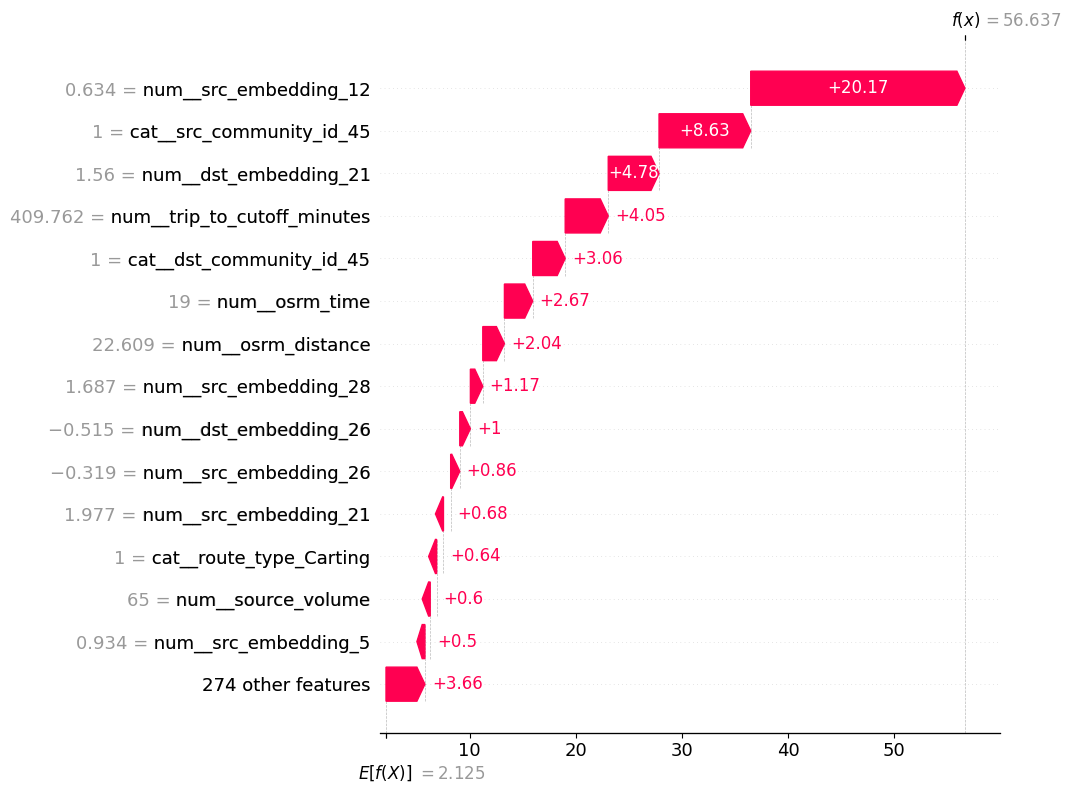


Trip: trip-153697923702522443


<Axes: >

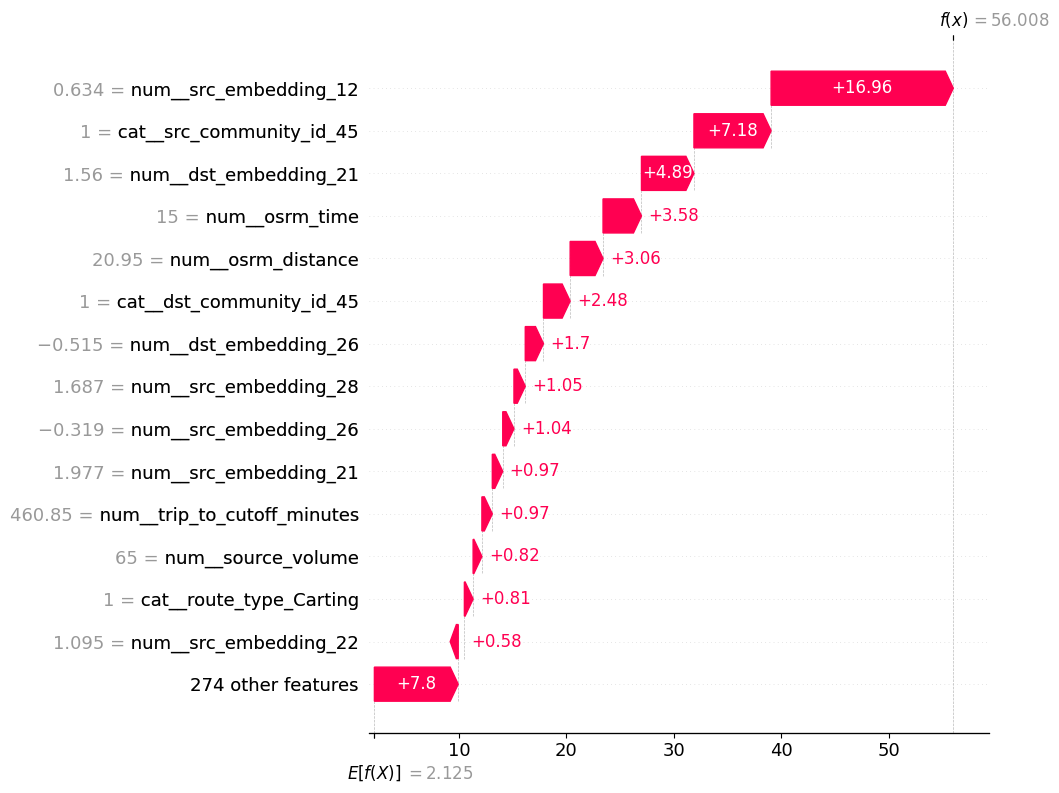


Trip: trip-153697923702522443


<Axes: >

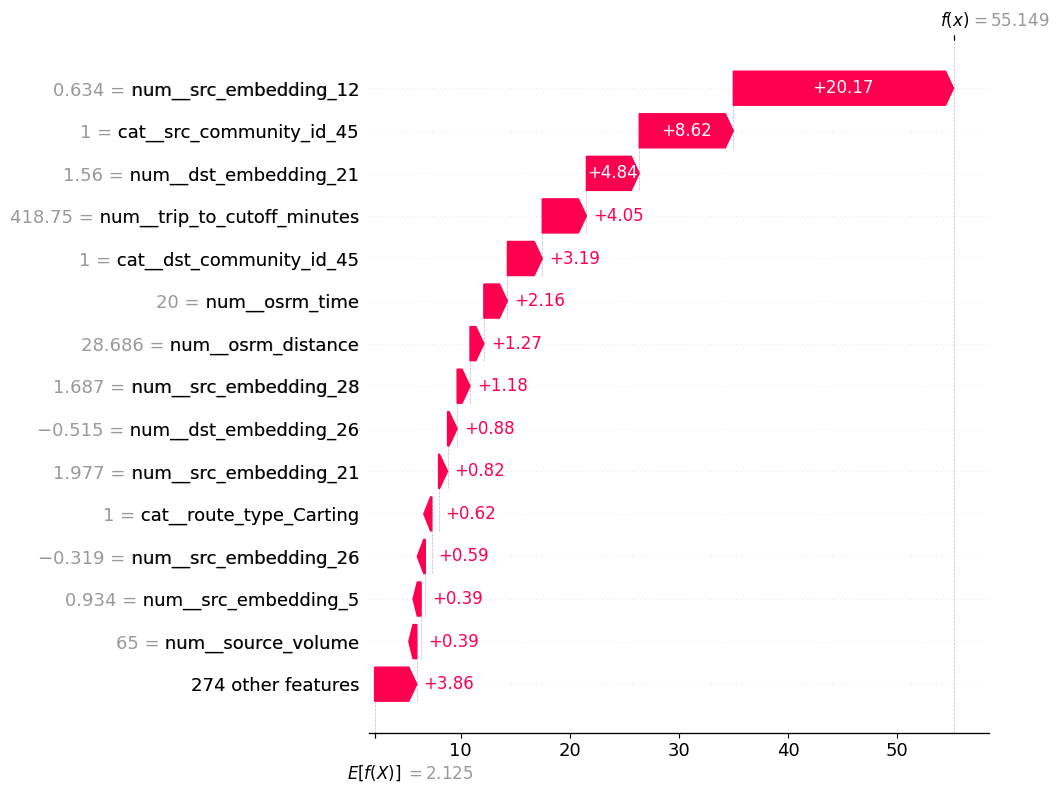


Trip: trip-153750335607956765


<Axes: >

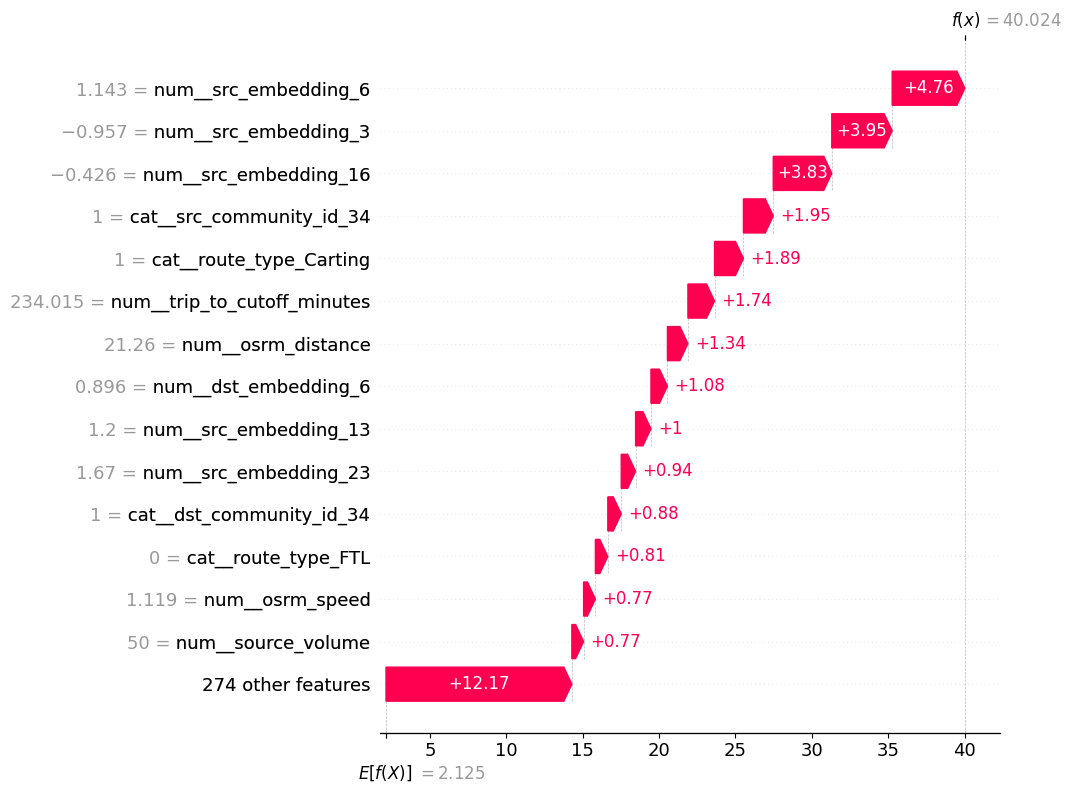


Trip: trip-153705622336805088


<Axes: >

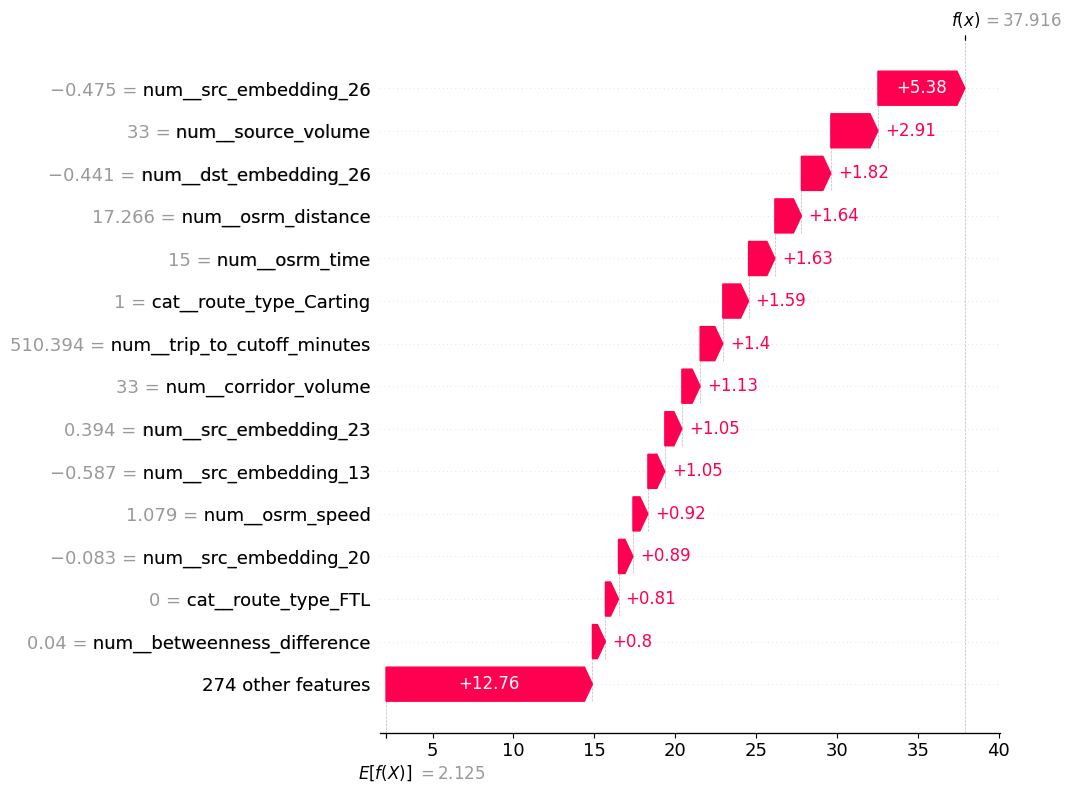


Trip: trip-153826219212835068


<Axes: >

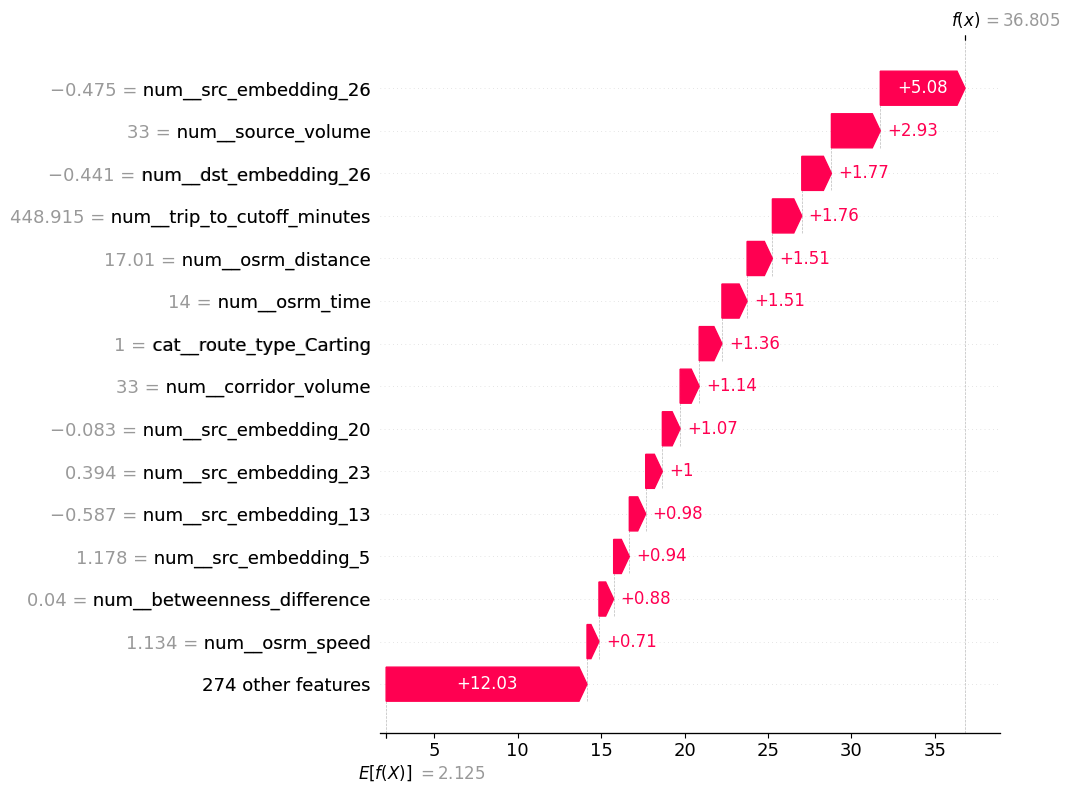


Trip: trip-153697923702522443


<Axes: >

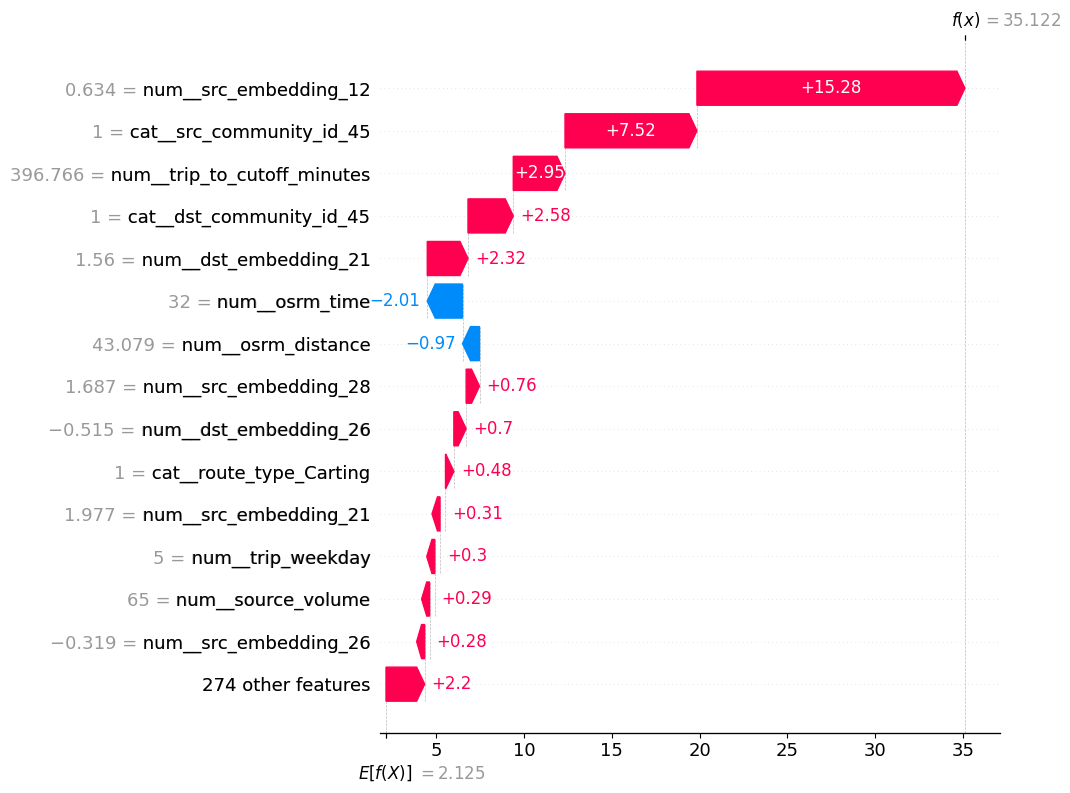


Trip: trip-153750335607956765


<Axes: >

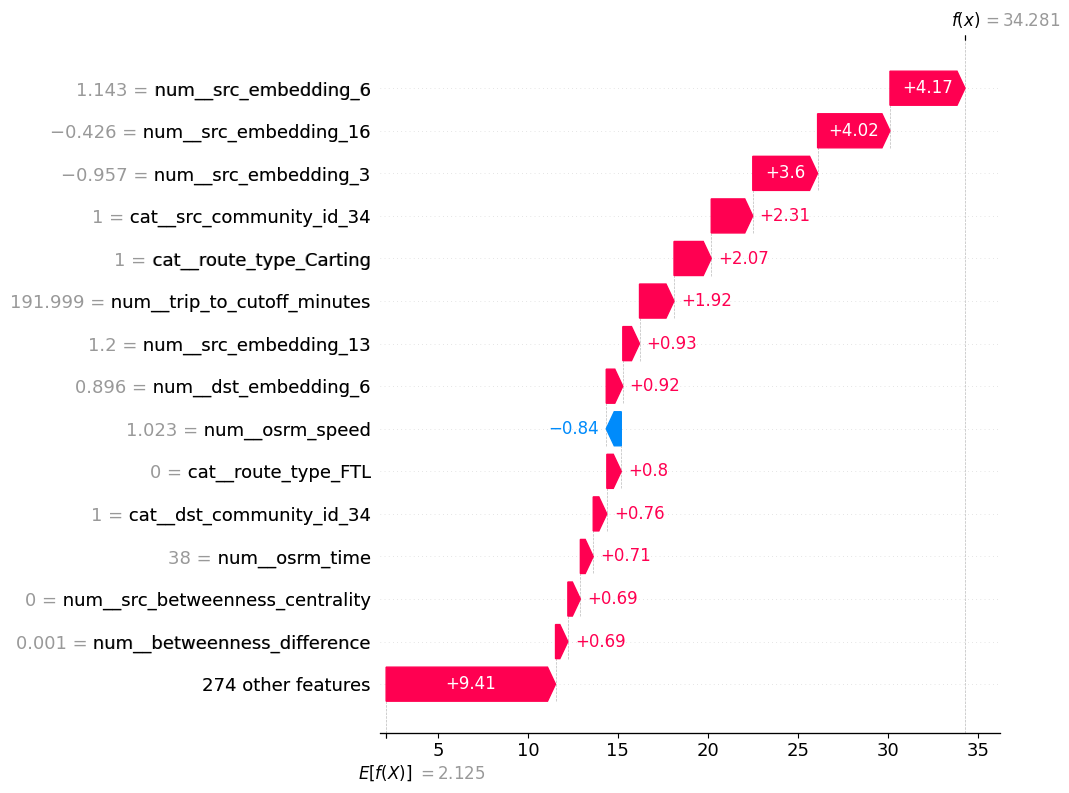


Trip: trip-153697923702522443


<Axes: >

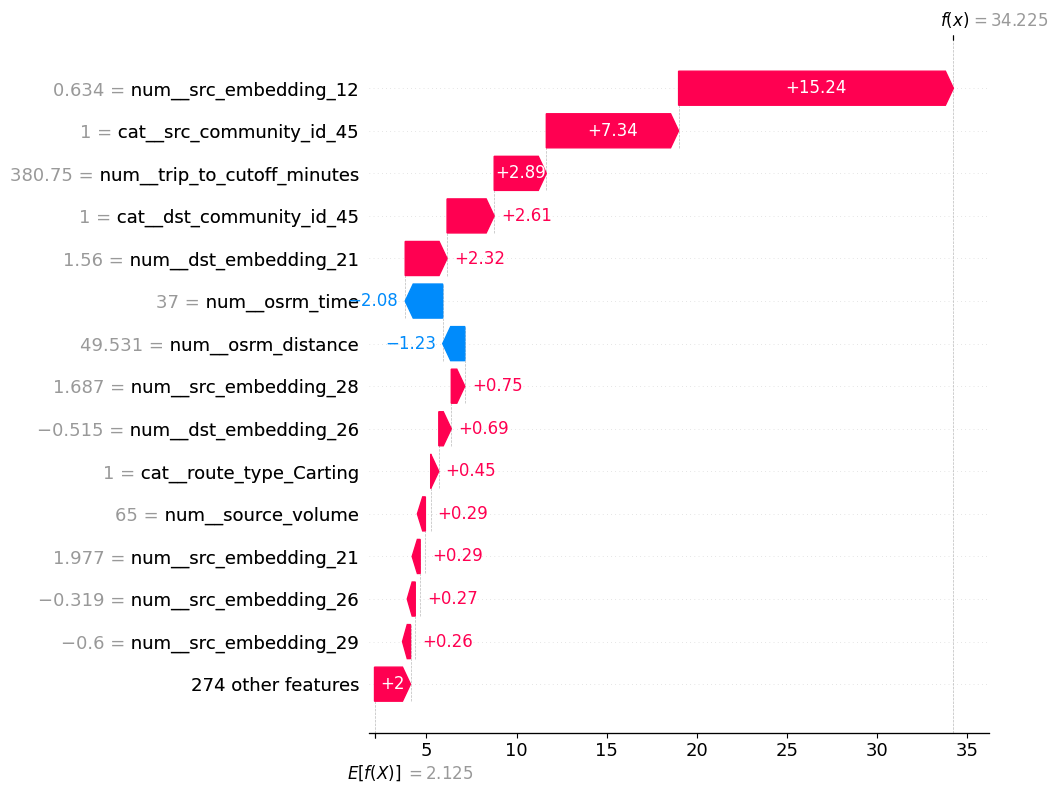


Trip: trip-153793221526410461


<Axes: >

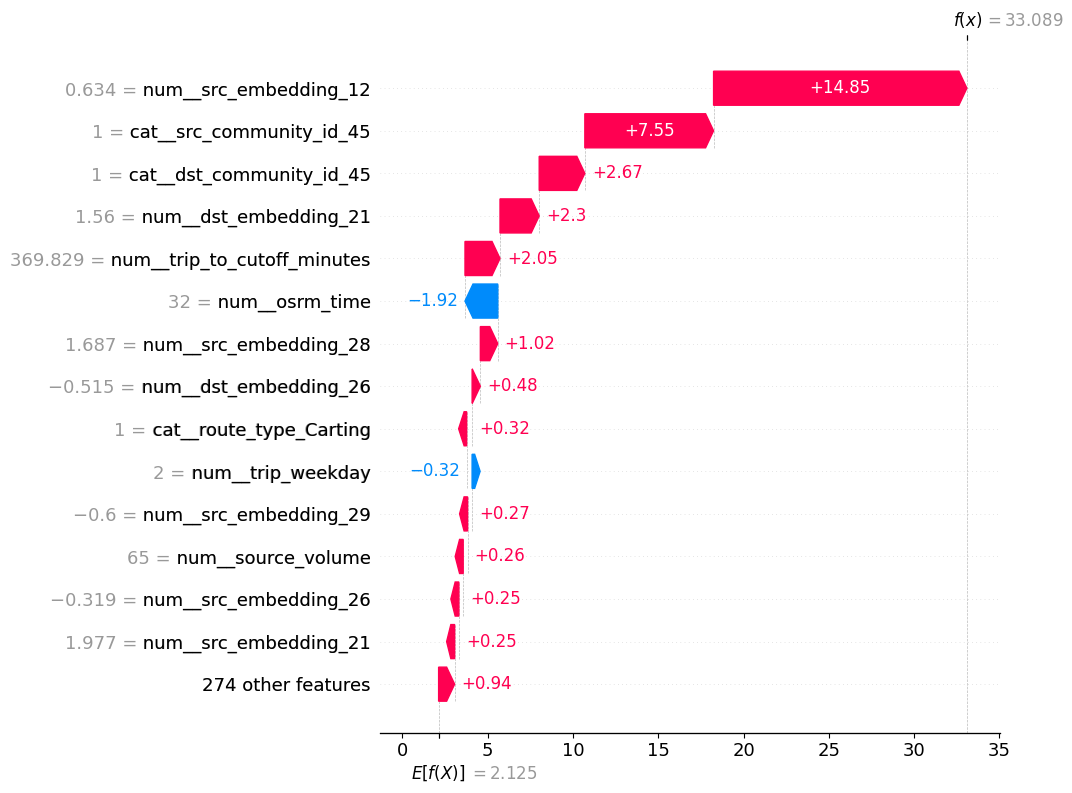

In [195]:
for idx in top_delay_indices:

    row_pos = np.where(
        test_df.index == idx
    )[0][0]

    print(
        "\nTrip:",
        test_df.loc[idx, "trip_uuid"]
    )

    display(
        shap.plots.waterfall(
            shap_explanation[row_pos],
            max_display=15,
            show=False
        )
    )

    plt.show()

In [196]:
best_shipments = (
    test_df
    .sort_values(
        "pred_factor",
        ascending=True
    )
)

In [197]:
best_shipments[
    [
        "trip_uuid",
        "pred_factor",
        "factor"
    ]
].head(20)

,trip_uuid,pred_factor,factor
79268,trip-153783566987892075,-2.656856,1.625000
86936,trip-153845985383498191,-0.790376,1.800000
8637,trip-153757512084871008,0.611273,1.240000
113609,trip-153852574051173098,0.633217,0.828571
64991,trip-153835368878968479,0.641967,0.857143
105512,trip-153748810509122771,0.654333,0.428571
105511,trip-153748810509122771,0.674858,0.314607
9735,trip-153739738946648248,0.675827,0.444444
8642,trip-153757512084871008,0.687752,5.833333
52699,trip-153818001841621876,0.690310,0.810811


In [198]:
best_idx = best_shipments.index[0]

row_pos = np.where(
    test_df.index == best_idx
)[0][0]

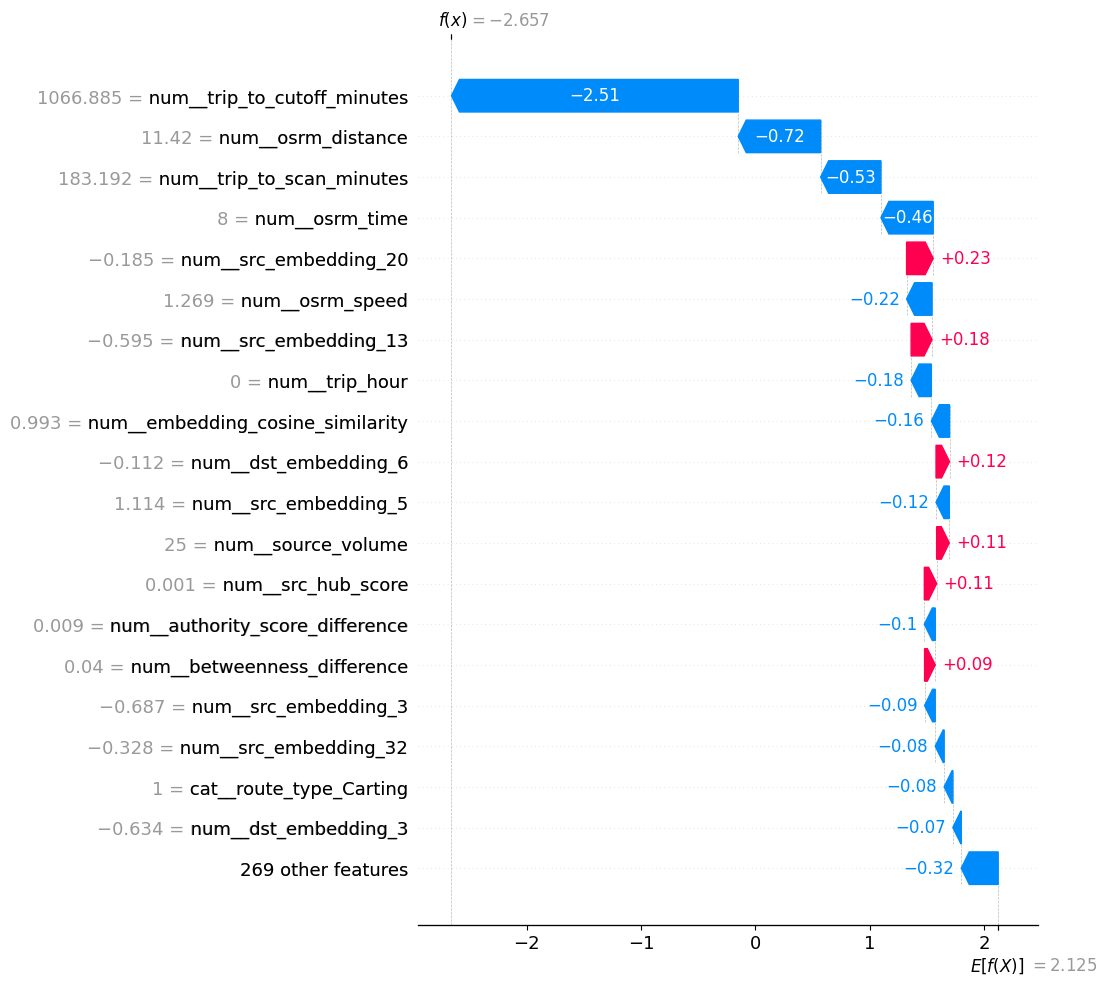

In [199]:
shap.plots.waterfall(
    shap_explanation[row_pos],
    max_display=20
)

In [200]:
# 1. Update system packages and install LaTeX dependencies
!apt-get update -qq
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic -qq

# 2. Convert the notebook directly inside your Google Drive folder
!jupyter nbconvert --to pdf "/content/drive/MyDrive/8.ipynb" --output-dir="/content/drive/MyDrive"

# 3. Optional: Automatically trigger a browser download of the finished PDF
from google.colab import files
try:
    files.download("/content/drive/MyDrive/8.pdf")
    print("Download started successfully!")
except Exception as e:
    print(f"Could not auto-download: {e}. You can find your PDF inside your Google Drive folder.")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[NbConvertApp] Converting notebook /content/drive/MyDrive/8.ipynb to pdf
[NbConvertApp] Support files will be in 8_files/
[NbConvertApp] Making directory ./8_files
[NbConvertApp] Writing 157637 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
object address  : 0x78336e3748e0
object refcount : 3
object type     : 0xa284e0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
^C
Could not auto-download: Cannot find file: /content/drive/MyDrive/8.pdf. You can find your PDF inside your Google Drive folder.


-----------------------SHAP ANALYSIS COMPLETE-----------------------------------------------------------

In [201]:
source_risk = (
    test_df
    .groupby("source_center")
    .agg(
        shipments=("factor", "count"),
        avg_actual_factor=("factor", "mean"),
        avg_pred_factor=("pred_factor", "mean")
    )
    .query("shipments >= 30")
    .sort_values(
        "avg_pred_factor",
        ascending=False
    )
)

source_risk.head(20)

,shipments,avg_actual_factor,avg_pred_factor
source_center,,,
IND110064AAA,55,3.967136,4.160798
IND401104AAA,34,3.664310,3.720812
IND713205AAB,45,3.188002,3.573974
IND585307AAB,35,3.423773,3.444894
IND742401AAA,35,2.530417,3.306894
IND400072AAD,59,2.868604,3.190488
IND400072AAB,176,2.981223,3.073716
IND742101AAC,48,3.104322,2.980215
IND834002AAB,96,2.881604,2.940887


In [202]:
destination_risk = (
    test_df
    .groupby("destination_center")
    .agg(
        shipments=("factor", "count"),
        avg_actual_factor=("factor", "mean"),
        avg_pred_factor=("pred_factor", "mean")
    )
    .query("shipments >= 30")
    .sort_values(
        "avg_pred_factor",
        ascending=False
    )
)

destination_risk.head(20)

,shipments,avg_actual_factor,avg_pred_factor
destination_center,,,
IND827013AAA,30,4.116408,4.270982
IND273014AAB,30,2.976949,3.509326
IND110044AAB,30,4.061008,3.353766
IND421302AAR,41,3.181078,3.227300
IND400072AAB,113,3.320488,3.226516
IND742102AAB,46,2.868875,3.216205
IND400102AAC,54,3.052708,3.081106
IND401104AAA,87,3.155896,3.071529
IND635802AAB,31,2.118555,3.064908


In [203]:
test_df["corridor"] = (
    test_df["source_center"].astype(str)
    + " -> "
    + test_df["destination_center"].astype(str)
)

corridor_risk = (
    test_df
    .groupby("corridor")
    .agg(
        shipments=("factor", "count"),
        avg_actual_factor=("factor", "mean"),
        avg_pred_factor=("pred_factor", "mean")
    )
    .query("shipments >= 20")
    .sort_values(
        "avg_pred_factor",
        ascending=False
    )
)

corridor_risk.head(30)

,shipments,avg_actual_factor,avg_pred_factor
corridor,,,
IND847226AAA -> IND842001AAA,20,9.984745,9.444787
IND834002AAB -> IND827013AAA,30,4.116408,4.270982
IND110064AAA -> IND000000ACB,54,3.985046,4.174373
IND713205AAB -> IND712311AAA,27,3.766994,4.127813
IND400102AAC -> IND421302AAG,23,3.560649,4.085294
IND811399AAA -> IND110044AAB,21,5.111362,3.924801
IND742148AAA -> IND742225AAA,24,3.907906,3.900519
IND585314AAA -> IND585104AAA,22,2.759841,3.803690
IND635601AAB -> IND635802AAB,20,2.651290,3.726513


In [204]:
source_risk.to_csv(
    f"{REPORT_DIR}/phase7_source_risk.csv"
)

destination_risk.to_csv(
    f"{REPORT_DIR}/phase7_destination_risk.csv"
)

corridor_risk.to_csv(
    f"{REPORT_DIR}/phase7_corridor_risk.csv"
)

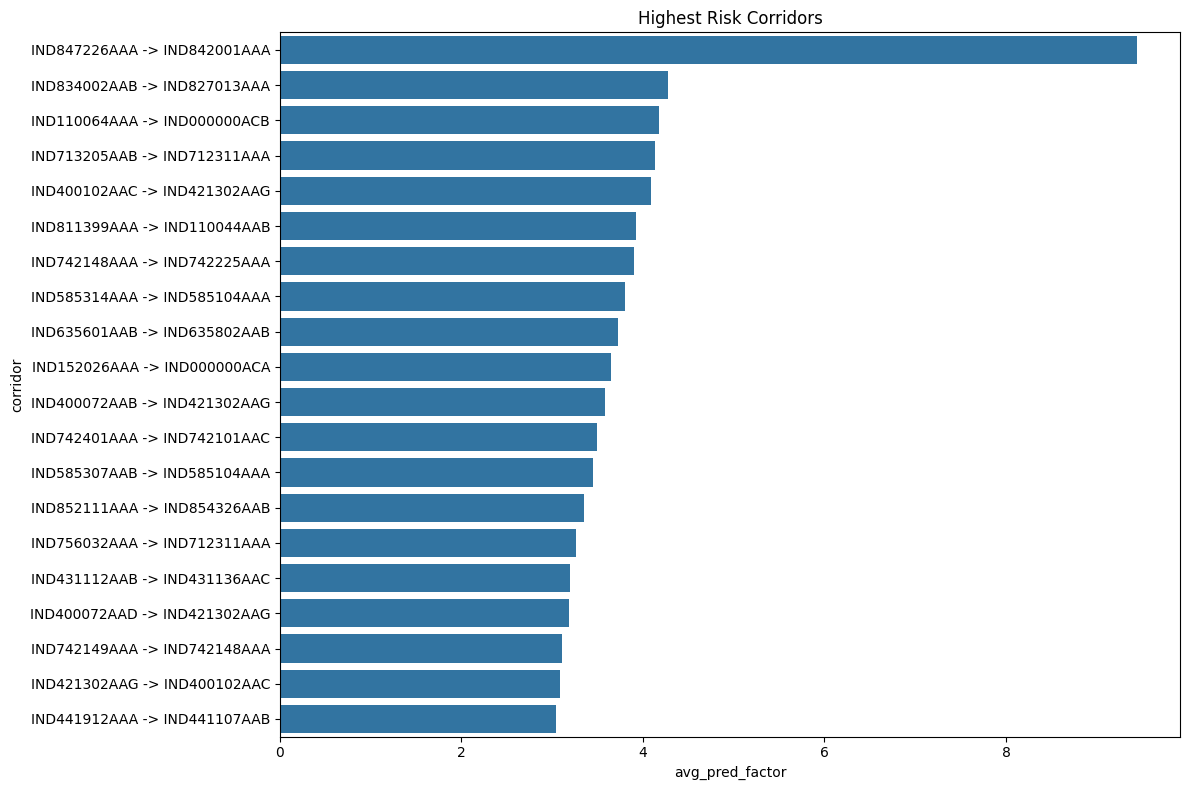

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(
    data=corridor_risk.head(20).reset_index(),
    x="avg_pred_factor",
    y="corridor"
)

plt.title(
    "Highest Risk Corridors"
)

plt.tight_layout()
plt.show()

In [206]:
corridor_risk["impact_score"] = (
    corridor_risk["avg_pred_factor"]
    * corridor_risk["shipments"]
)

corridor_impact = (
    corridor_risk
    .sort_values(
        "impact_score",
        ascending=False
    )
)

corridor_impact.head(20)

,shipments,avg_actual_factor,avg_pred_factor,impact_score
corridor,,,,
IND000000ACB -> IND562132AAA,1070,1.744211,1.688481,1806.674239
IND000000ACB -> IND712311AAA,597,2.435245,2.160609,1289.883763
IND000000ACB -> IND501359AAE,443,1.925686,1.828349,809.958484
IND562132AAA -> IND000000ACB,460,1.785745,1.698787,781.441933
IND000000ACB -> IND421302AAG,391,1.897166,1.991502,778.677256
IND421302AAG -> IND131028AAB,318,1.853458,1.923782,611.762614
IND501359AAE -> IND462022AAA,214,2.039759,2.240027,479.365784
IND395023AAA -> IND110037AAM,258,1.794088,1.843195,475.544295
IND421302AAG -> IND712311AAA,220,1.945452,2.158974,474.974174


In [207]:
source_risk["impact_score"] = (
    source_risk["avg_pred_factor"]
    * source_risk["shipments"]
)

source_impact = (
    source_risk
    .sort_values(
        "impact_score",
        ascending=False
    )
)

source_impact.head(20)

,shipments,avg_actual_factor,avg_pred_factor,impact_score
source_center,,,,
IND000000ACB,4836,1.925056,1.885241,9117.025903
IND562132AAA,2005,1.817903,1.826613,3662.359147
IND421302AAG,1643,2.120249,2.120747,3484.387296
IND411033AAA,678,1.920938,2.012705,1364.613721
IND501359AAE,678,1.954012,2.009997,1362.778249
IND712311AAA,477,2.195399,2.283553,1089.254600
IND395023AAA,545,1.911993,1.868178,1018.157239
IND110037AAM,469,2.253018,2.118428,993.542934
IND160002AAC,422,1.899615,1.886956,796.295571


In [208]:
destination_risk["impact_score"] = (
    destination_risk["avg_pred_factor"]
    * destination_risk["shipments"]
)

destination_impact = (
    destination_risk
    .sort_values(
        "impact_score",
        ascending=False
    )
)

destination_impact.head(20)

,shipments,avg_actual_factor,avg_pred_factor,impact_score
destination_center,,,,
IND000000ACB,2512,1.893871,1.873031,4705.054674
IND562132AAA,1993,1.765580,1.731575,3451.029305
IND421302AAG,1241,2.226164,2.343425,2908.189927
IND712311AAA,1092,2.442546,2.441265,2665.861545
IND501359AAE,1126,1.934613,1.967197,2215.064008
IND411033AAA,709,2.076402,2.059124,1459.918864
IND462022AAA,650,2.130733,2.212693,1438.250141
IND131028AAB,659,1.869114,1.901896,1253.349374
IND110037AAM,493,2.025727,2.085853,1028.325746


In [209]:
top_corridors = (
    corridor_impact
    .head(20)
    .reset_index()
)

top_corridors

,corridor,shipments,avg_actual_factor,avg_pred_factor,impact_score
0,IND000000ACB -> IND562132AAA,1070,1.744211,1.688481,1806.674239
1,IND000000ACB -> IND712311AAA,597,2.435245,2.160609,1289.883763
2,IND000000ACB -> IND501359AAE,443,1.925686,1.828349,809.958484
3,IND562132AAA -> IND000000ACB,460,1.785745,1.698787,781.441933
4,IND000000ACB -> IND421302AAG,391,1.897166,1.991502,778.677256
5,IND421302AAG -> IND131028AAB,318,1.853458,1.923782,611.762614
6,IND501359AAE -> IND462022AAA,214,2.039759,2.240027,479.365784
7,IND395023AAA -> IND110037AAM,258,1.794088,1.843195,475.544295
8,IND421302AAG -> IND712311AAA,220,1.945452,2.158974,474.974174
9,IND562132AAA -> IND462022AAA,208,2.328937,2.198276,457.241445


In [210]:
top_source_facilities = (
    source_impact
    .head(20)
    .reset_index()
)

top_source_facilities

,source_center,shipments,avg_actual_factor,avg_pred_factor,impact_score
0,IND000000ACB,4836,1.925056,1.885241,9117.025903
1,IND562132AAA,2005,1.817903,1.826613,3662.359147
2,IND421302AAG,1643,2.120249,2.120747,3484.387296
3,IND411033AAA,678,1.920938,2.012705,1364.613721
4,IND501359AAE,678,1.954012,2.009997,1362.778249
5,IND712311AAA,477,2.195399,2.283553,1089.254600
6,IND395023AAA,545,1.911993,1.868178,1018.157239
7,IND110037AAM,469,2.253018,2.118428,993.542934
8,IND160002AAC,422,1.899615,1.886956,796.295571
9,IND751002AAB,296,2.008521,2.199491,651.049323


In [211]:
top_destination_facilities = (
    destination_impact
    .head(20)
    .reset_index()
)

top_destination_facilities

,destination_center,shipments,avg_actual_factor,avg_pred_factor,impact_score
0,IND000000ACB,2512,1.893871,1.873031,4705.054674
1,IND562132AAA,1993,1.765580,1.731575,3451.029305
2,IND421302AAG,1241,2.226164,2.343425,2908.189927
3,IND712311AAA,1092,2.442546,2.441265,2665.861545
4,IND501359AAE,1126,1.934613,1.967197,2215.064008
5,IND411033AAA,709,2.076402,2.059124,1459.918864
6,IND462022AAA,650,2.130733,2.212693,1438.250141
7,IND131028AAB,659,1.869114,1.901896,1253.349374
8,IND110037AAM,493,2.025727,2.085853,1028.325746
9,IND160002AAC,505,2.004790,1.978636,999.211273


In [212]:
top_corridors.to_csv(
    f"{REPORT_DIR}/phase7_top_impact_corridors.csv",
    index=False
)

top_source_facilities.to_csv(
    f"{REPORT_DIR}/phase7_top_source_facilities.csv",
    index=False
)

top_destination_facilities.to_csv(
    f"{REPORT_DIR}/phase7_top_destination_facilities.csv",
    index=False
)

In [213]:
top_corridors.to_csv(
    f"{REPORT_DIR}/phase7_top_impact_corridors.csv",
    index=False
)

top_source_facilities.to_csv(
    f"{REPORT_DIR}/phase7_top_source_facilities.csv",
    index=False
)

top_destination_facilities.to_csv(
    f"{REPORT_DIR}/phase7_top_destination_facilities.csv",
    index=False
)

In [214]:
executive_findings = pd.DataFrame({

    "Finding":[

        "Graph intelligence improves ETA prediction",

        "Node2Vec embeddings are primary graph signal",

        "Centrality contributes meaningful signal",

        "Community structure contributes minor signal",

        "Edge intelligence adds measurable value",

        "Trip-to-cutoff delay is top operational driver",

        "Carting routes inflate ETA",

        "Source and corridor congestion matter",

        "Super hubs dominate network behavior"

    ],

    "Evidence":[

        "MAE improved from 0.4443 to 0.4056",

        "65.2% of graph SHAP importance",

        "16.6% of graph SHAP importance",

        "5.2% of graph SHAP importance",

        "12.9% of graph SHAP importance",

        "Top SHAP operational feature",

        "Top ETA inflation feature",

        "Source volume and corridor volume rank highly",

        "IND000000ACB dominates impact rankings"

    ]

})

executive_findings

,Finding,Evidence
0,Graph intelligence improves ETA prediction,MAE improved from 0.4443 to 0.4056
1,Node2Vec embeddings are primary graph signal,65.2% of graph SHAP importance
2,Centrality contributes meaningful signal,16.6% of graph SHAP importance
3,Community structure contributes minor signal,5.2% of graph SHAP importance
4,Edge intelligence adds measurable value,12.9% of graph SHAP importance
5,Trip-to-cutoff delay is top operational driver,Top SHAP operational feature
6,Carting routes inflate ETA,Top ETA inflation feature
7,Source and corridor congestion matter,Source volume and corridor volume rank highly
8,Super hubs dominate network behavior,IND000000ACB dominates impact rankings


In [215]:
executive_findings.to_csv(
    f"{REPORT_DIR}/phase7_executive_findings.csv",
    index=False
)

In [225]:

importance_df.to_csv(
    f"{REPORT_DIR}/phase7_global_shap_importance.csv",
    index=False
)

positive_df.to_csv(
    f"{REPORT_DIR}/phase7_eta_inflation_drivers.csv",
    index=False
)

negative_df.to_csv(
    f"{REPORT_DIR}/phase7_eta_reduction_drivers.csv",
    index=False
)

graph_breakdown.to_csv(
    f"{REPORT_DIR}/phase7_graph_contribution_breakdown.csv",
    index=False
)

top_corridors.to_csv(
    f"{REPORT_DIR}/phase7_high_risk_corridors.csv"
)

top_sources.to_csv(
    f"{REPORT_DIR}/phase7_high_impact_sources.csv"
)

top_destinations.to_csv(
    f"{REPORT_DIR}/phase7_high_impact_destinations.csv"
)

NameError: name 'top_sources' is not defined

In [228]:
plt.savefig(
    f"{REPORT_DIR}/phase7_shap_summary.png",
    bbox_inches="tight"
)

In [229]:
phase7_summary = {
    "model": "LightGBM Full Graph + Edge",
    "mae": 0.4056,
    "rmse": 0.9366,
    "r2": 0.6370,
    "graph_signal": {
        "embeddings_pct": 65.24,
        "centrality_pct": 16.59,
        "edge_pct": 12.94,
        "community_pct": 5.24
    }
}

In [231]:
import json

with open(
    f"{REPORT_DIR}/phase7_summary.json",
    "w"
) as f:
    json.dump(
        phase7_summary,
        f,
        indent=4
    )

In [227]:
import os

os.listdir(REPORT_DIR)

['phase6_model_results.csv',
 'phase6_ablation_results.csv',
 'phase6_feature_importance.csv',
 'phase7_global_feature_importance.csv',
 'phase7_graph_family_contribution.csv',
 'phase7_graph_component_breakdown.csv',
 'phase7_eta_inflation_drivers.csv',
 'phase7_inflation_family_breakdown.csv',
 'phase7_graph_eta_inflation_drivers.csv',
 'phase7_eta_inflation_drivers_business.csv',
 'phase7_eta_reduction_drivers.csv',
 'phase7_source_risk.csv',
 'phase7_destination_risk.csv',
 'phase7_corridor_risk.csv',
 'phase7_top_impact_corridors.csv',
 'phase7_top_source_facilities.csv',
 'phase7_top_destination_facilities.csv',
 'phase7_executive_findings.csv',
 'phase7_global_shap_importance.csv',
 'phase7_graph_contribution_breakdown.csv',
 'phase7_high_risk_corridors.csv']

In [232]:
phase7_summary = {
    "final_model": "LightGBM Graph + Edge",
    "mae": 0.4056,
    "rmse": 0.9366,
    "r2": 0.6370,
    "embedding_pct": 65.24,
    "centrality_pct": 16.59,
    "edge_pct": 12.94,
    "community_pct": 5.24
}

In [233]:
import json

with open(
    f"{REPORT_DIR}/phase7_summary.json",
    "w"
) as f:
    json.dump(
        phase7_summary,
        f,
        indent=4
    )